# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  **Stellar Classification** by **fedesoriano** on *Kaggle*
   <!--Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.>


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
#Type your code here
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
#Memilih Dataset
#Format : [nama dataset,file csv]
ds_link = ["fedesoriano/stellar-classification-dataset-sdss17","star_classification.csv"]

In [3]:
def load_ds(ds_link = ds_link):
  df = kagglehub.dataset_load(
    kagglehub.KaggleDatasetAdapter.PANDAS,
    ds_link[0],
    ds_link[1],
  )
  return df

df = load_ds(ds_link)

Using Colab cache for faster access to the 'stellar-classification-dataset-sdss17' dataset.


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [8]:
df.head()

,num__obj_ID,num__alpha,num__delta,num__u,num__g,num__r,num__i,num__z,num__run_ID,num__rerun_ID,num__cam_col,num__field_ID,num__spec_obj_ID,num__redshift,num__plate,num__MJD,num__fiber_ID,cat__class
0,-0.445634,-0.434604,0.425529,0.059755,0.054926,0.403962,0.046007,0.003937,-0.445535,0.0,-0.952553,-0.718947,0.228609,0.079557,0.228633,0.423203,-1.021342,0.0
1,0.018740,-0.339921,0.363402,0.088045,0.072456,1.584406,1.185097,0.092835,0.018646,0.0,0.937920,-0.450509,1.797912,0.277096,1.797924,1.420729,-0.081883,0.0
2,-0.445633,-0.367251,0.582713,0.103327,0.067165,0.519745,0.150019,0.008808,-0.445535,0.0,-0.952553,-0.443798,-0.190037,0.092423,-0.190025,0.001854,-0.551612,0.0
3,-0.147311,1.669523,-1.249105,0.004921,0.102210,1.059904,0.807610,0.018321,-0.147278,0.0,-0.322395,0.187031,1.358962,0.486770,1.358942,1.354927,1.195196,0.0
4,1.842768,1.737310,-0.150242,-0.080055,-0.092948,-1.697421,-1.767887,-0.098468,1.842792,0.0,-0.322395,-0.329712,0.333328,-0.630267,0.333297,0.330860,1.441070,0.0


In [9]:
#Melakukan preprocessing untuk mempermudah analisis korelasi data
#Kode di bawah diambil dari modul Dicoding

numeric_features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

scaler = StandardScaler()
encoder = OrdinalEncoder()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', scaler, numeric_features),
        ('cat', encoder, categorical_features)
    ]
)

clean_arr = preprocessor.fit_transform(df)
feature_names = preprocessor.get_feature_names_out()
clean_df = pd.DataFrame(clean_arr, columns=feature_names)

#Untuk menghapus beberapa kolom dari dataframe agar grafik lebih rapi:
deleted_columns = ['num__run_ID','num__rerun_ID','num__MJD','num__fiber_ID','num__field_ID']
clean_df = clean_df.drop(columns=deleted_columns)

#Untuk menentukan kolom target
target_column = "cat__class"

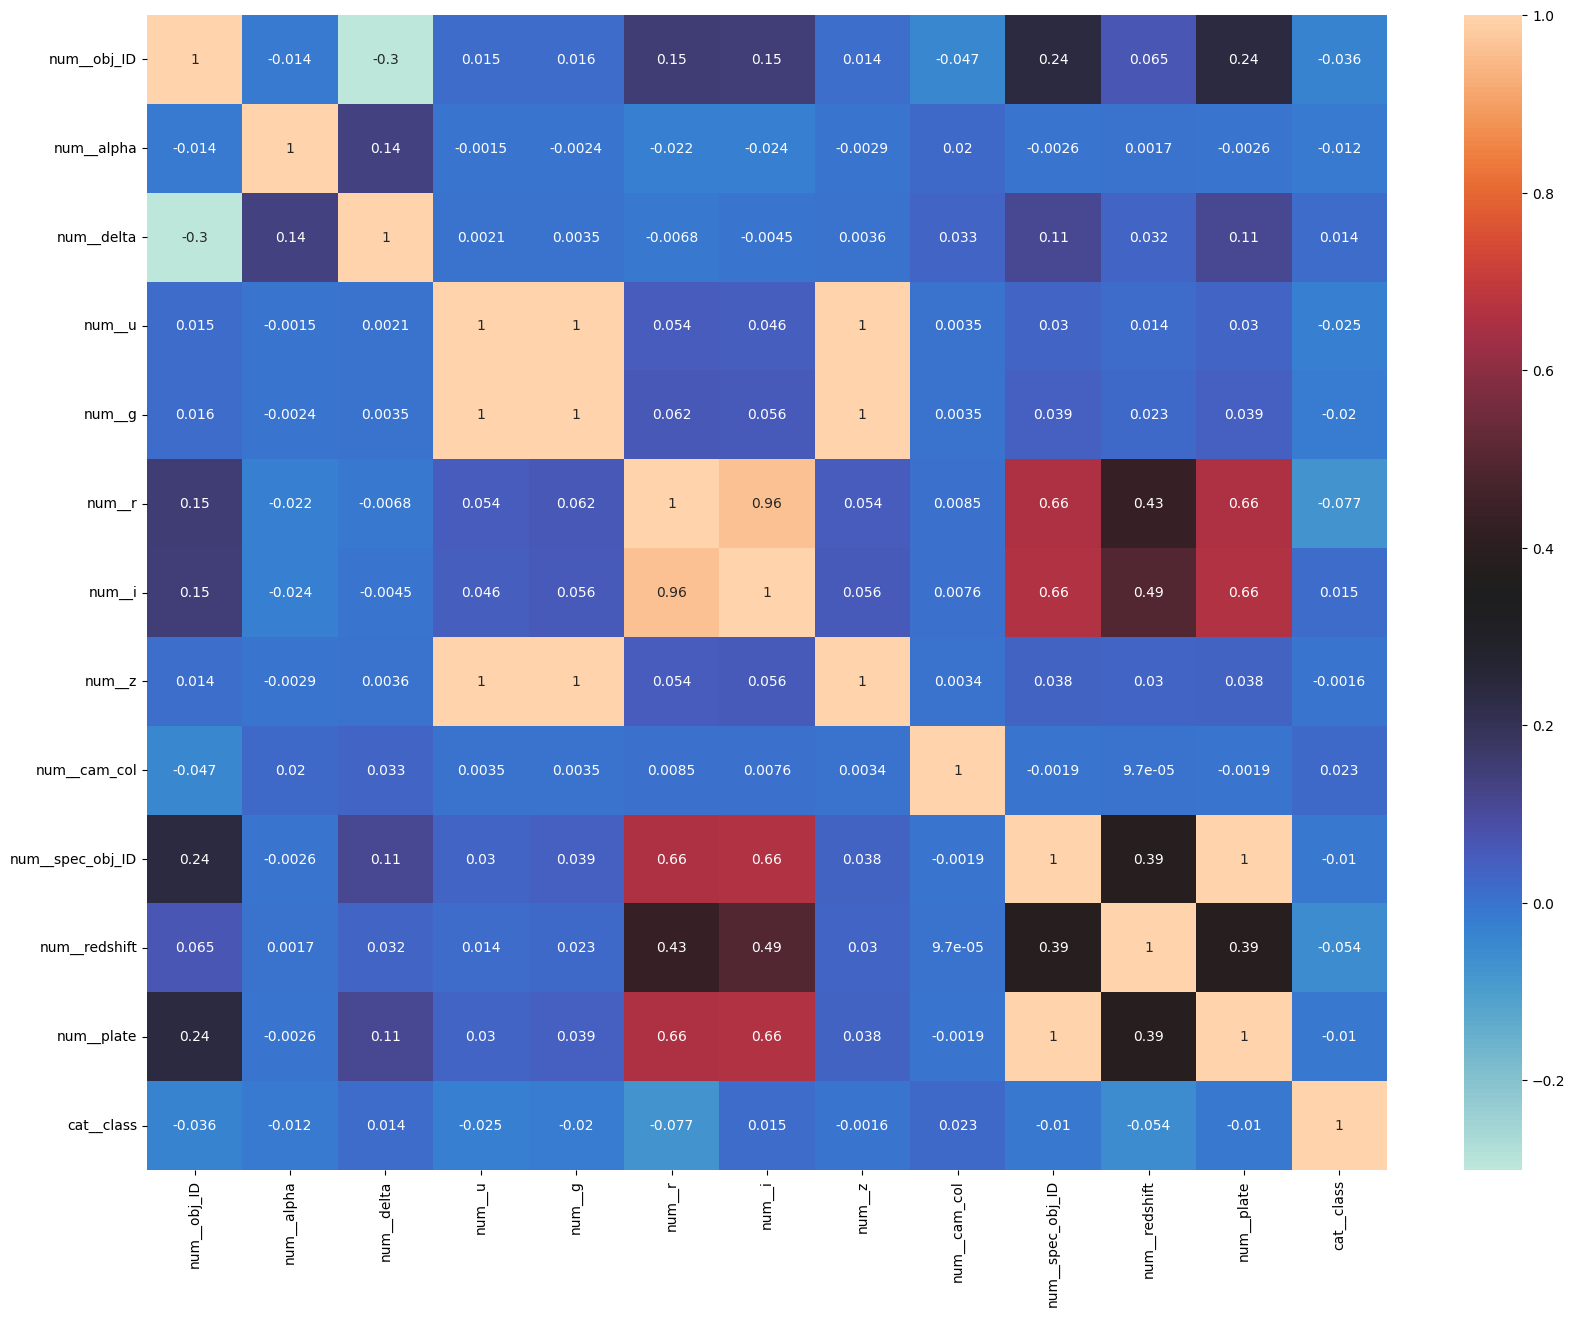

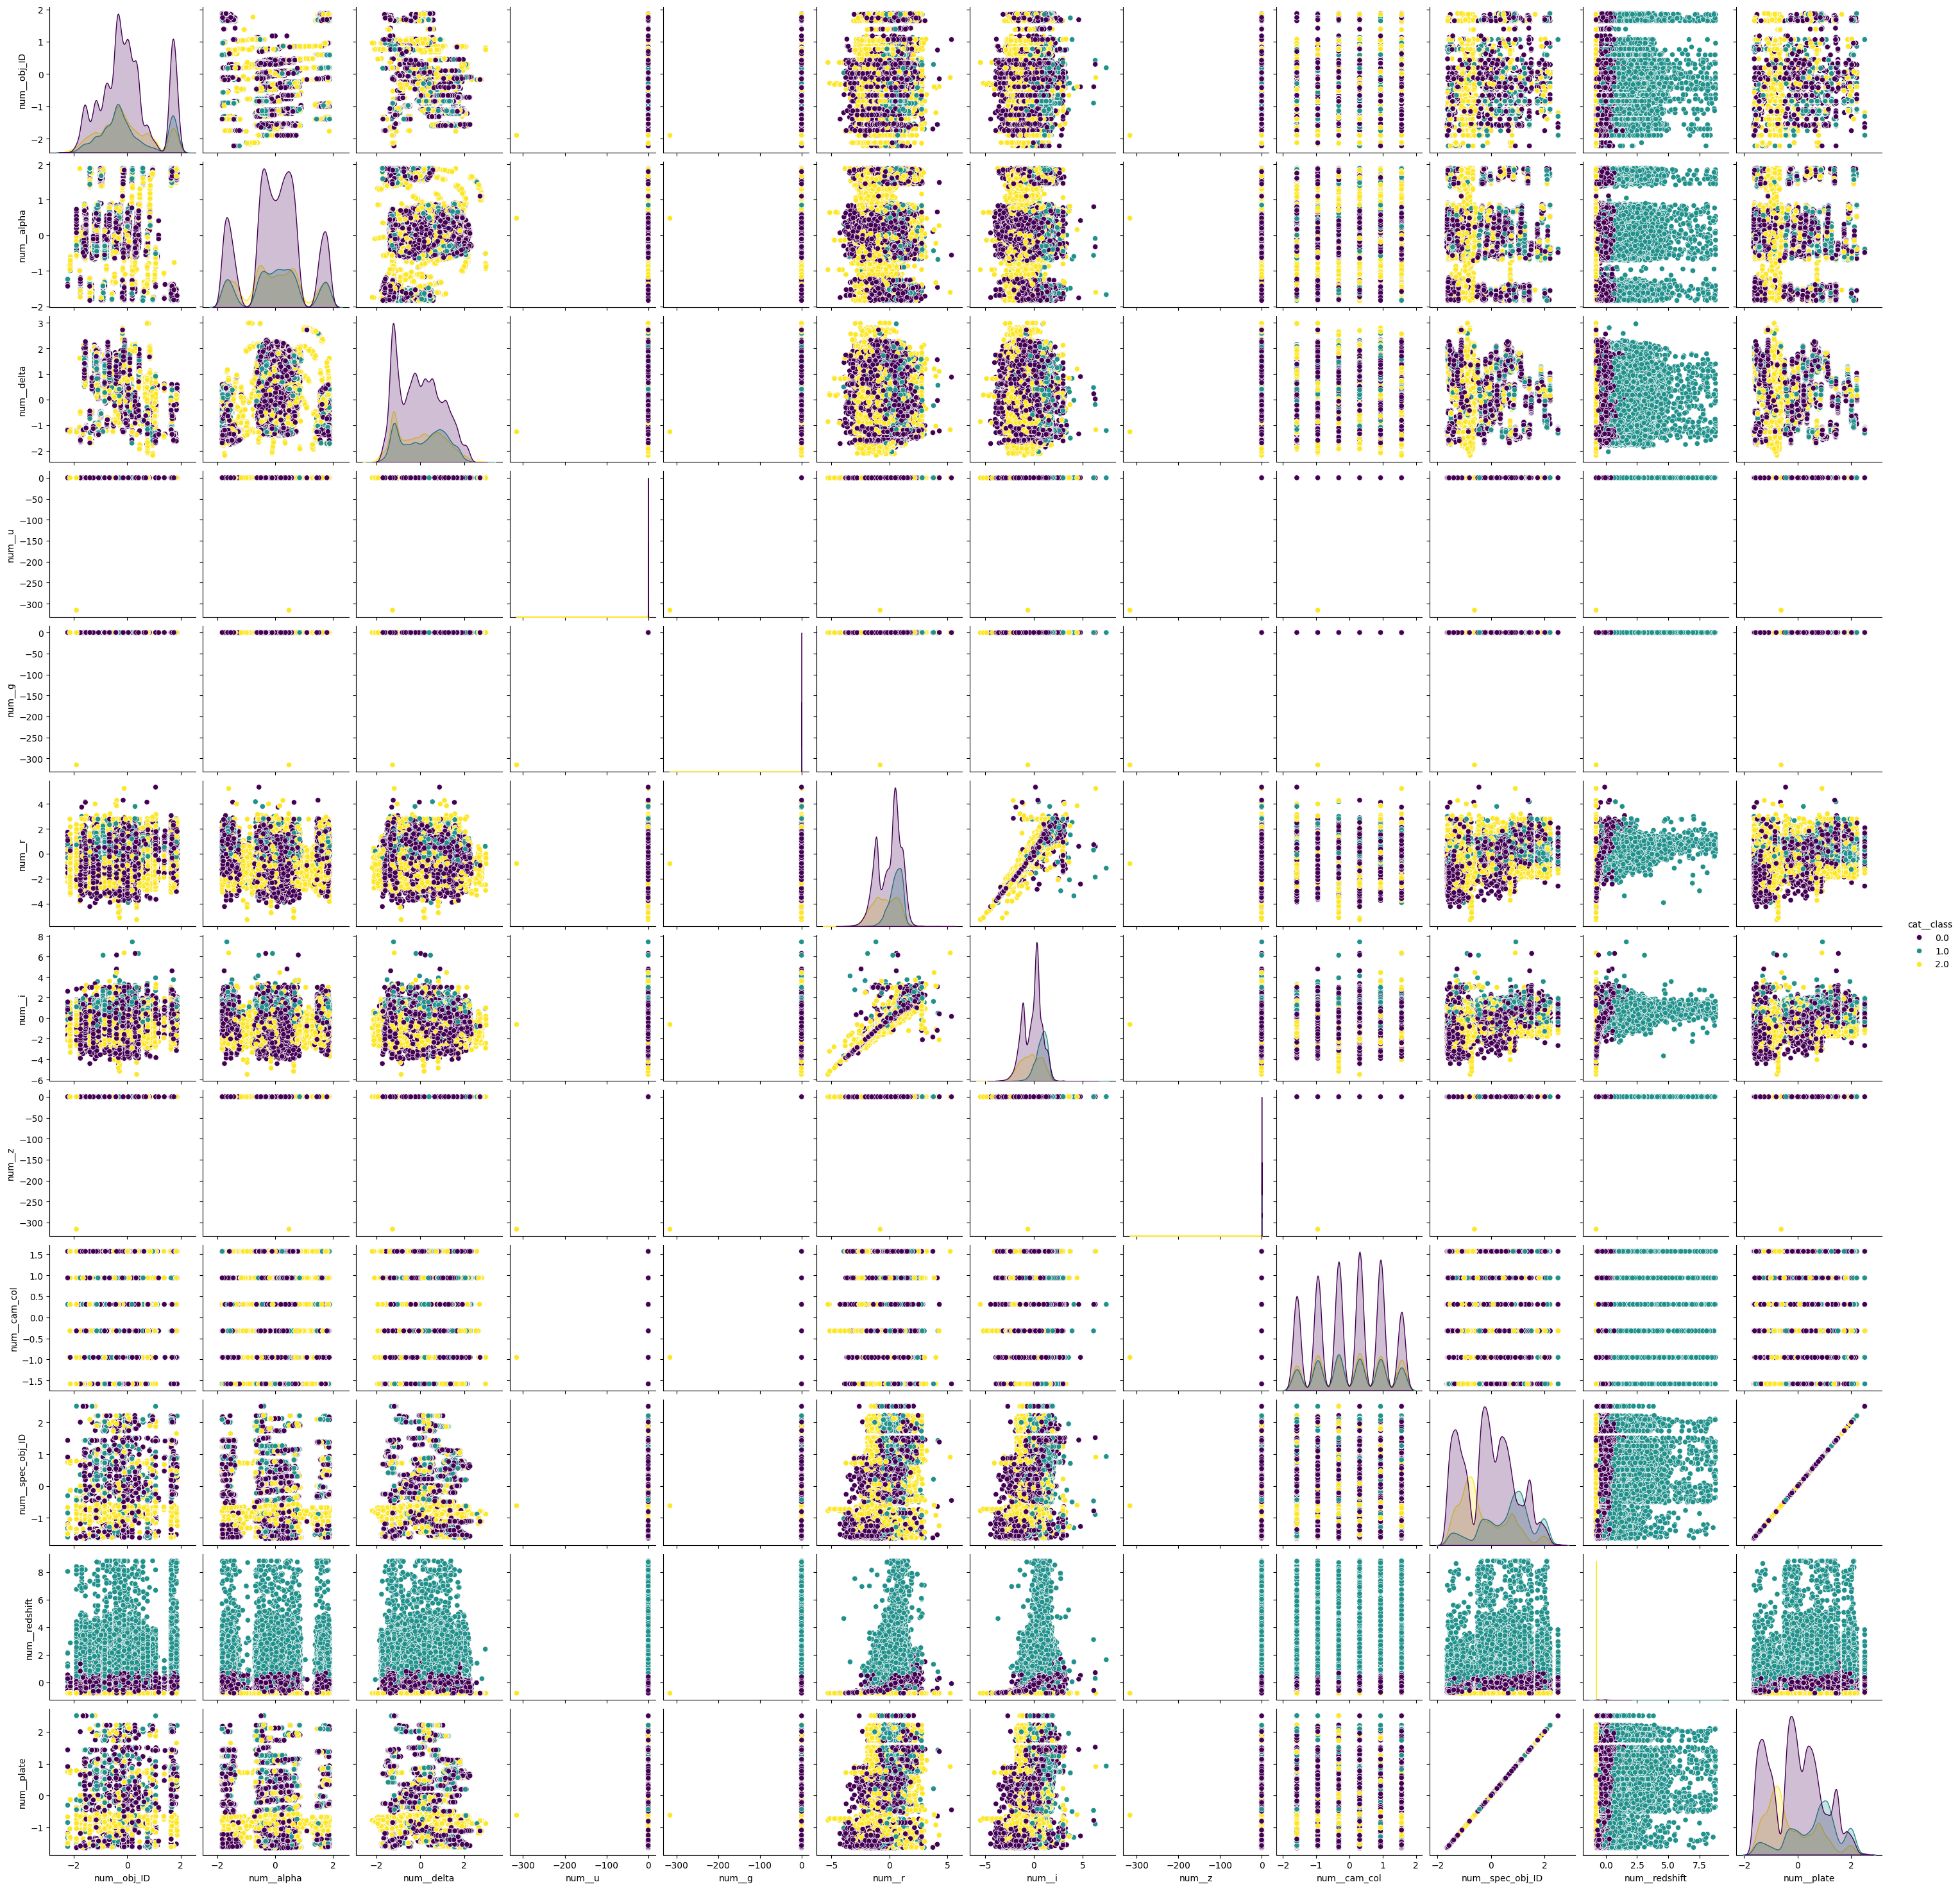

In [10]:
#Jika menentukan kolom target, jalankan kode ini dan bukan yang di bawah
#Menampilkan hubungan antara variabel
plt.figure(figsize=(20, 15))
sns.heatmap(clean_df.corr(), annot=True, cmap="icefire")
sns.pairplot(data=clean_df, hue=target_column, palette="viridis")
plt.show()


In [ ]:
#Sebagian kode di sini diadaptasi dari kode di GitHub saya.
#Menampilkan hubungan antara variabel
plt.figure(figsize=(20, 15))
sns.heatmap(clean_df.corr(), annot=True, cmap="icefire")
sns.pairplot(data=clean_df)
plt.tight_layout()
plt.show()

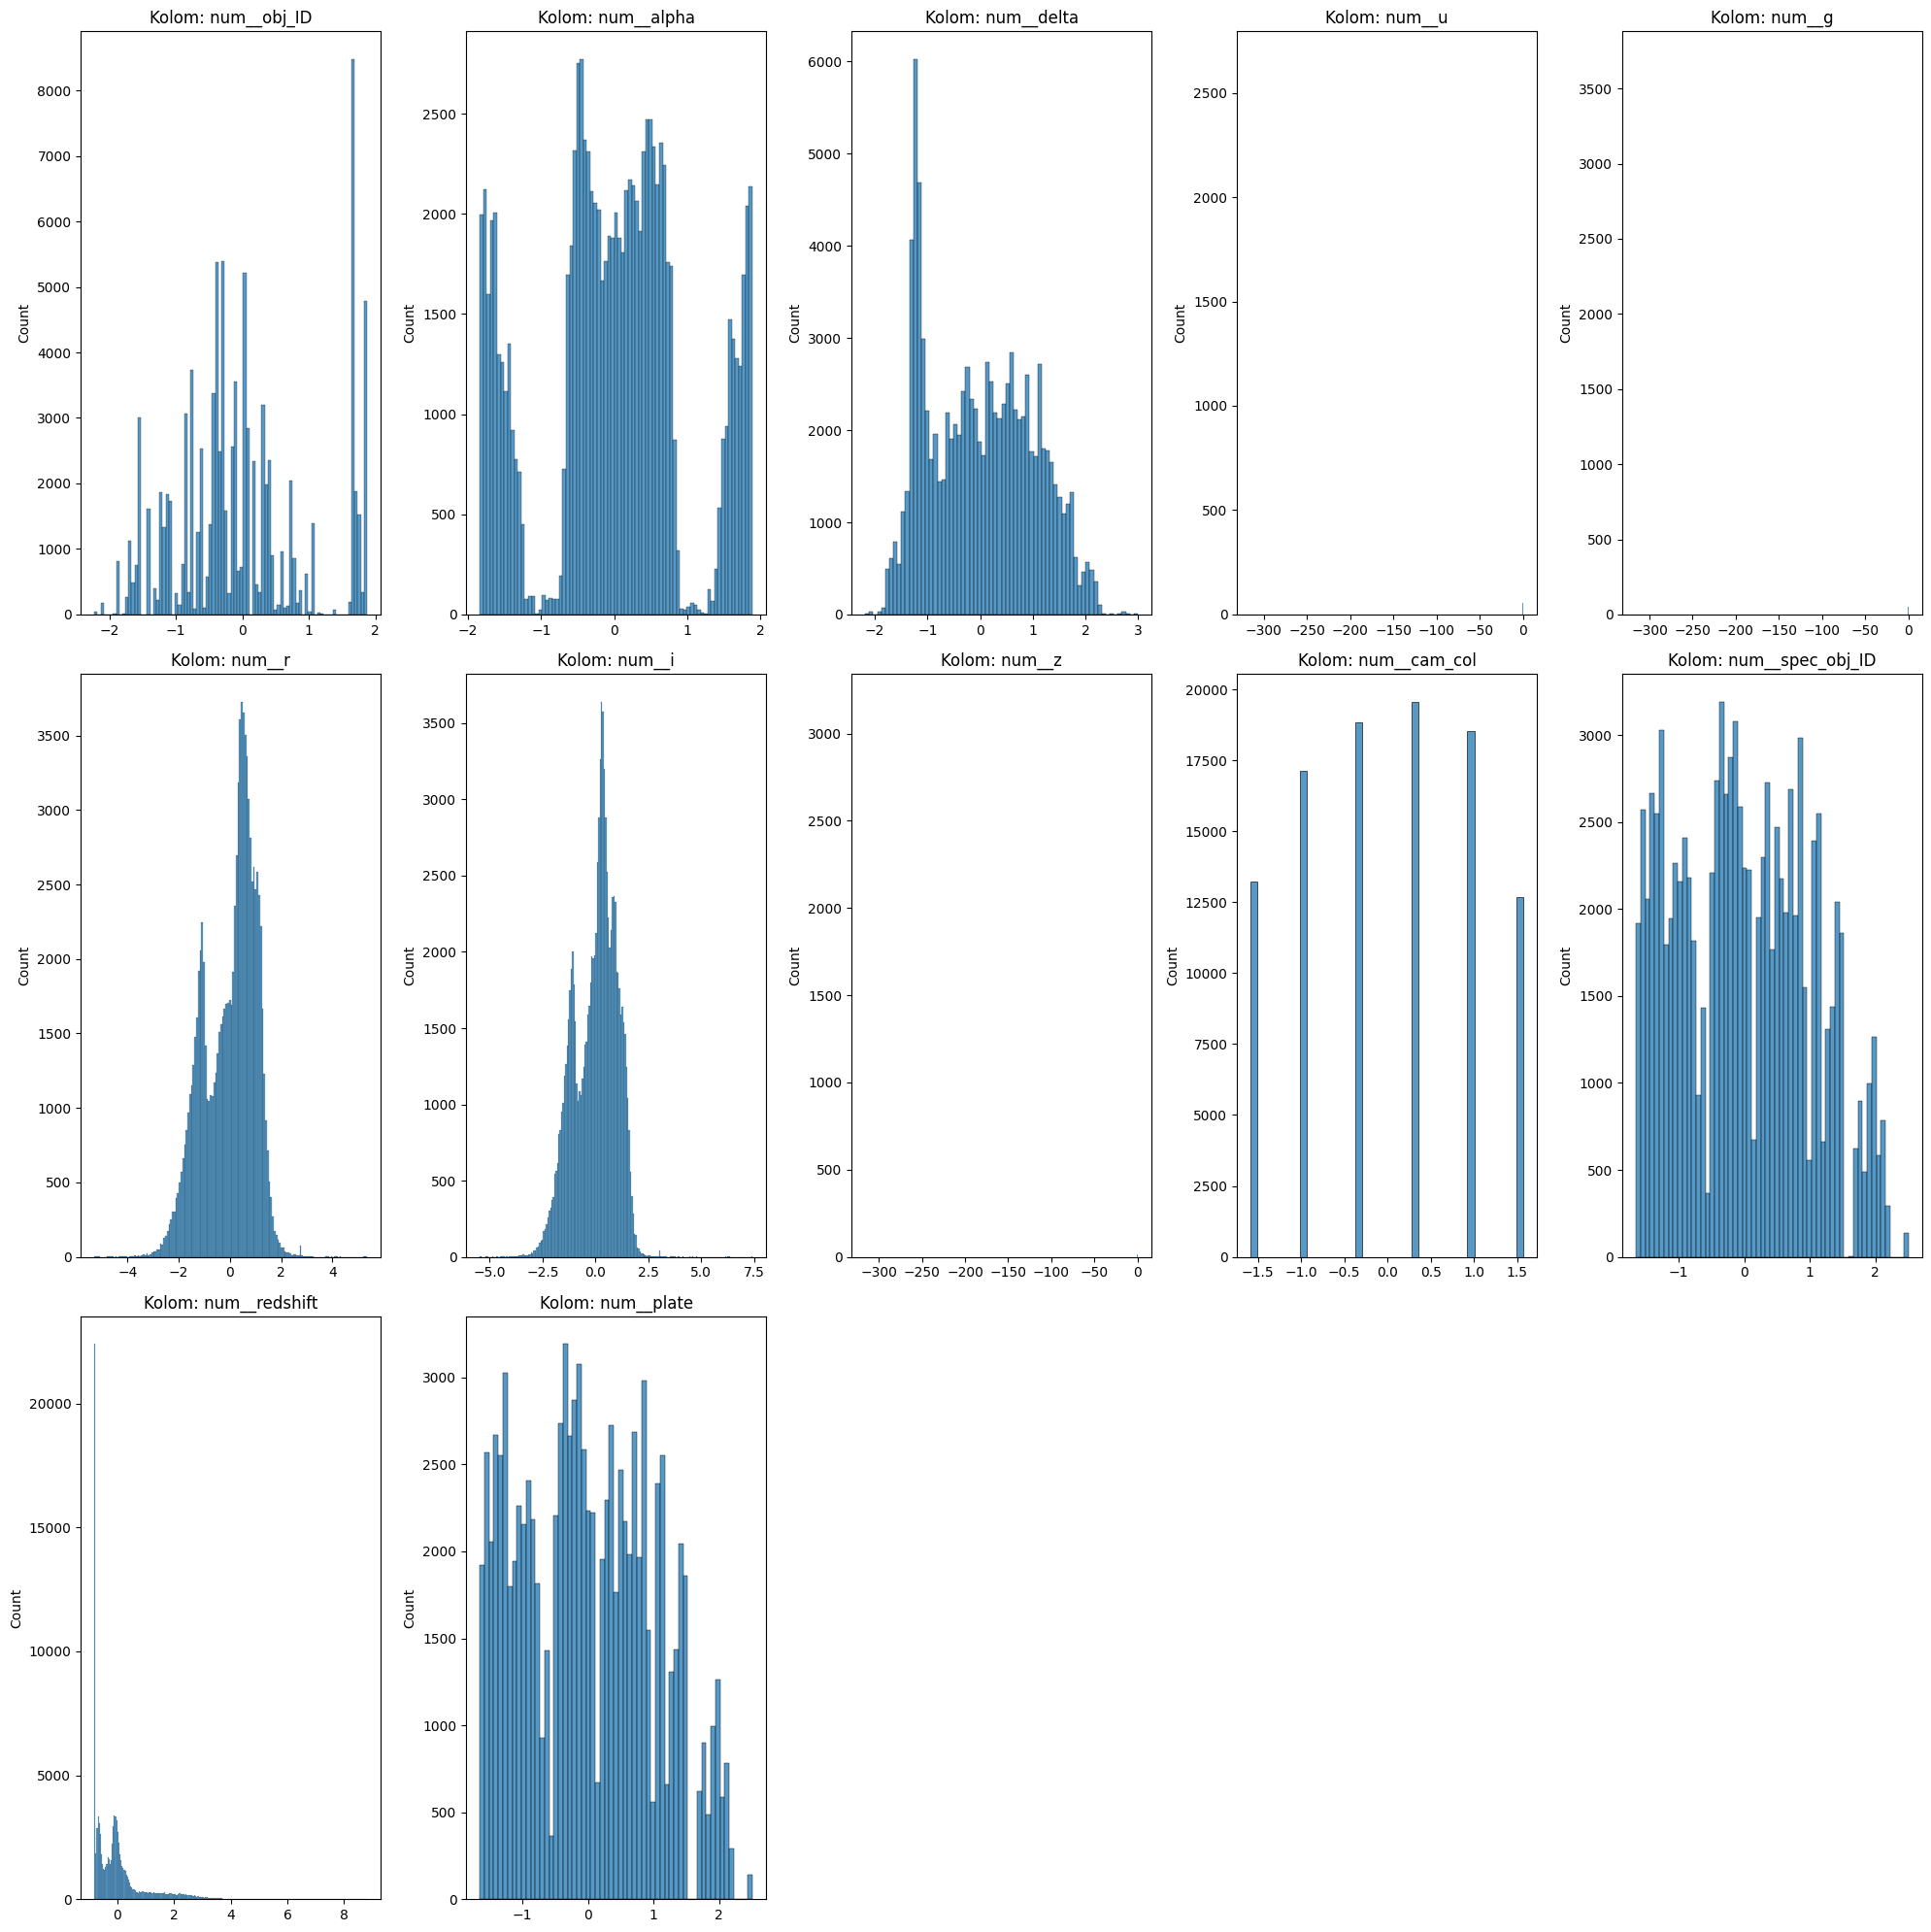

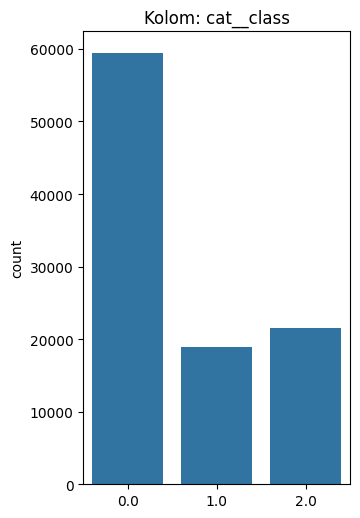

In [11]:
#Menampilkan distribusi data tiap variabel
num_cols = [col for col in clean_df.columns if col.startswith('num__')]
cat_cols = [col for col in clean_df.columns if col.startswith('cat__')]

#Kolom numerik menggunakan histplot:
fig, axes = plt.subplots(3, 5, figsize=(20, 5 * 4))
axes = axes.flatten()
for i,col in enumerate(num_cols):
  sns.histplot(data=clean_df, x=col, ax=axes[i])
  axes[i].set_title(f"Kolom: {col}")
  axes[i].set_xlabel("")
for j in range(i + 1, len(axes)):
  fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#Kolom kategorik menggunakan countplots:
fig, axes = plt.subplots(3, 5, figsize=(20, 5 * 4))
axes = axes.flatten()
for i,col in enumerate(cat_cols):
  sns.countplot(data=clean_df, x=col, ax=axes[i])
  axes[i].set_title(f"Kolom: {col}")
  axes[i].set_xlabel("")
for j in range(i + 1, len(axes)):
  fig.delaxes(axes[j])

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [12]:
#Mendefinisikan fungsi:
def del_missing(df):
  df_missing = df.dropna() #Delete empty rows
  df_missing = df_missing.dropna(how='all', axis=1) #Delete empty columns
  df_missing = df_missing.drop_duplicates() #Delete duplicates
  return df_missing

def cap_outlier(df):
  df_cap = df.copy()
  df_cap.info()

  for col in df_cap.columns:
    upper = np.percentile(df_cap[col], 95)
    lower = np.percentile(df_cap[col], 5)
    df_cap[col] = np.clip(df_cap[col], lower, upper)
  return df_cap

#Sebagian kode di bawah diambil dari modul Dicoding
def data_preprocessing(df,target_col,save_path,file_path,chosen_features=None):

  if chosen_features is not None:
    valid_features = []
    for i in chosen_features:
      if i in df.columns:
        valid_features.push(i)
    data = df[chosen_features]
  else:
    data = df.copy()

  data = del_missing(data)

  numeric_features = data.select_dtypes(include=['float64', 'int64']).columns.tolist()
  categorical_features = data.select_dtypes(include=['object']).columns.tolist()
  column_names = data.columns

  column_names = data.columns.drop(target_col) #Drop target column

  df_header = pd.DataFrame(columns=column_names)          #
  df_header.to_csv(file_path, index=False)                # Menyimpan nama-nama kolom ke file CSV
  print(f"Nama kolom berhasil disimpan ke: {file_path}")  #

  #Menghapus target col dari daftar kolom
  if target_col in numeric_features:
        numeric_features.remove(target_col)
  if target_col in categorical_features:
      categorical_features.remove(target_col)

  numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('outlier', FunctionTransformer(cap_outlier)),
        ('scaler', StandardScaler())
  ])

  categorical_transformer = Pipeline(steps=[
      ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
      ('encoder', OneHotEncoder(handle_unknown='ignore'))
  ])

  preprocessor = ColumnTransformer(
      transformers=[
          ('num', numeric_transformer, numeric_features),
          ('cat', categorical_transformer, categorical_features)
      ]
  )

  preprocessor.set_output(transform="pandas")

  X = data.drop(columns=[target_col])
  y = data[target_col]

  #Split ds and transform
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

  X_train = preprocessor.fit_transform(X_train)
  X_test = preprocessor.transform(X_test)

  joblib.dump(preprocessor, save_path)

  return X_train, X_test, y_train, y_test



In [13]:
data_preprocessing(df=df,target_col="class",save_path="preprocessing.joblib",file_path="dataset.csv")

Nama kolom berhasil disimpan ke: dataset.csv
<class 'pandas.core.frame.DataFrame'>
Index: 70000 entries, 76513 to 15795
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   obj_ID       70000 non-null  float64
 1   alpha        70000 non-null  float64
 2   delta        70000 non-null  float64
 3   u            70000 non-null  float64
 4   g            70000 non-null  float64
 5   r            70000 non-null  float64
 6   i            70000 non-null  float64
 7   z            70000 non-null  float64
 8   run_ID       70000 non-null  float64
 9   rerun_ID     70000 non-null  float64
 10  cam_col      70000 non-null  float64
 11  field_ID     70000 non-null  float64
 12  spec_obj_ID  70000 non-null  float64
 13  redshift     70000 non-null  float64
 14  plate        70000 non-null  float64
 15  MJD          70000 non-null  float64
 16  fiber_ID     70000 non-null  float64
dtypes: float64(17)
memory usage: 9.6 MB
<class '

(       num__obj_ID  num__alpha  num__delta    num__u    num__g    num__r  \
 76513    -0.761086   -0.489565   -1.047137 -0.925043 -1.196993 -1.246148   
 60406    -0.302912    0.503226    0.478528 -1.051040 -0.896598 -0.613624   
 27322    -0.652334    0.437500    1.659554 -1.058245 -1.604590 -1.698121   
 53699     0.034597    0.012657    0.630365 -1.723800 -1.881899 -1.883598   
 65412     0.428654    0.160498   -0.285096  1.024456  1.043103  0.473950   
 ...            ...         ...         ...       ...       ...       ...   
 6265     -0.675752    0.683681    0.666240 -0.596410 -0.163368  0.346974   
 54886    -0.861557   -0.060759    1.563368 -1.489503 -1.881899 -1.883598   
 76820    -0.404487   -0.215783    0.766143  0.876796  0.393744  0.055002   
 860       0.785511   -1.278595   -0.758961 -1.723800 -1.881899 -1.883598   
 15795     0.046698    0.129979    0.510645  1.335754  0.240248 -0.213990   
 
          num__i    num__z  num__run_ID  num__rerun_ID  num__cam_col  \
 7